# Week (1,2) EDA And Data Preprocessing. 


# Task a: Pulling sample data.


In [19]:
!curl -L "https://docs.google.com/uc?export=download&id=19TRiv2giWEpBpHL3fXrq__5-6VO_5WK7" -o ../data/sample_7.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
100 7368k  100 7368k    0     0   250k      0  0:00:29  0:00:29 --:--:--  554k3419k    0     0   156k      0  0:00:47  0:00:21  0:00:26  439k


# Task b: Imputing missing data.

In [20]:
#load required packages
import pandas as pd 
import numpy as np
import plotly 

In [22]:
# load data 
sample_7_df = pd.read_csv("../data/sample_7.csv")
# take a peak view of our data 
sample_7_df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2013,Ford,Explorer,XLT,SUV,automatic,1fm5k7d80dgb98533,mi,25.0,42011.0,black,black,ford motor credit company llc,18000.0,Thu Mar 05 2015 01:00:00 GMT-0800 (PST)
1,2011,Ford,Ranger,XLT,SuperCab,automatic,1ftlr4fe9bpa61239,in,25.0,47930.0,white,gray,fiserv/citizens one auto finance,15000.0,Wed Jan 28 2015 16:00:00 GMT-0800 (PST)
2,2014,Subaru,Outback,2.5i Premium PZEV,Wagon,automatic,4s4brbcc1e3260991,nj,43.0,12495.0,blue,black,freehold dodge inc,22750.0,Wed Mar 04 2015 01:30:00 GMT-0800 (PST)
3,2014,FIAT,500L,Pop,Wagon,automatic,zfbcfaah5ez016657,ca,4.0,13427.0,white,black,hertz corporation/gdp,12000.0,Tue Dec 23 2014 12:30:00 GMT-0800 (PST)
4,2014,Toyota,Camry,LE,sedan,automatic,4t1bf1fk7eu826832,wi,35.0,14998.0,red,beige,toyota motor sales usa inc/program,15300.0,Wed Jun 03 2015 03:00:00 GMT-0700 (PDT)


In [23]:
# some base dataset summary
sample_7_df.describe()

,year,condition,odometer,sellingprice
count,50000.000000,48898.000000,49995.000000,49998.000000
mean,2010.036600,30.663054,68505.558296,13608.447818
std,3.992616,13.450842,53770.420823,9739.118819
min,1982.000000,1.000000,1.000000,100.000000
25%,2007.000000,23.000000,28669.500000,6900.000000
50%,2012.000000,35.000000,52310.000000,12100.000000
75%,2013.000000,42.000000,99044.000000,18200.000000
max,2015.000000,49.000000,999999.000000,163000.000000


In [26]:
# clean the date columns
sample_7_df['saledate'] = sample_7_df['saledate'].str.split(' GMT').str[0]
sample_7_df['saledate'] = pd.to_datetime(sample_7_df['saledate'], format='%a %b %d %Y %H:%M:%S', errors='coerce')



In [29]:
# Quick high-level overview
print("--- Dataset Shape ---")
print(f"{sample_7_df.shape[0]} rows, {sample_7_df.shape[1]} columns\n")

print("--- Missing Values per column ---")
print(sample_7_df.isnull().sum(), "\n")

--- Dataset Shape ---
50000 rows, 15 columns

--- Missing Values per column ---
year               0
make             887
model            899
trim             915
body            1125
transmission    6041
vin                0
state              0
condition       1102
odometer           5
color             67
interior          67
seller             0
sellingprice       2
saledate           5
dtype: int64 



In [30]:
print("Missing values BEFORE imputation:")
print(sample_7_df.isnull().sum()[sample_7_df.isnull().sum() > 0])
print("-" * 40)


# Drop rows where sellingprice or saledate are entirely missing
sample_7_df = sample_7_df.dropna(subset=['sellingprice', 'saledate'])

# Fill missing odometer with the median of its specific model year
sample_7_df['odometer'] = sample_7_df.groupby('year')['odometer'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else sample_7_df['odometer'].median())
)
# Fill missing condition with the median score of its specific model year
sample_7_df['condition'] = sample_7_df.groupby('year')['condition'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else df['condition'].median())
)
# --- STEP 3: SMART IMPUTATION FOR CATEGORICALS ---
# Group by Make and Model to find the most common transmission/body/color
categorical_cols = ['transmission', 'body', 'color', 'interior', 'make', 'model', 'trim']

for col in categorical_cols:
    # Use standard mode filling, fallback to global mode if a unique make/model combination isn't found
    sample_7_df[col] = sample_7_df.groupby(['make', 'model'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else (sample_7_df[col].mode()[0] if not sample_7_df[col].mode().empty else 'Unknown'))
    )

# Any lingering structural blanks (like seller) can be safely tagged as Unknown
sample_7_df['seller'] = sample_7_df['seller'].fillna('Unknown')


print("\nMissing values AFTER imputation:")
print(sample_7_df.isnull().sum())

Missing values BEFORE imputation:
make             887
model            899
trim             915
body            1125
transmission    6041
condition       1102
odometer           5
color             67
interior          67
sellingprice       2
saledate           5
dtype: int64
----------------------------------------

Missing values AFTER imputation:
year              0
make            899
model           899
trim            899
body            899
transmission    899
vin               0
state             0
condition         0
odometer          0
color           899
interior        899
seller            0
sellingprice      0
saledate          0
dtype: int64


In [32]:
# List of columns that still have that stubborn 899 missing values
stubborn_cols = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior']

# Fill any lingering blanks with 'Unknown'
for col in stubborn_cols:
    sample_7_df[col] = sample_7_df[col].fillna('Unknown')

print("Missing values AFTER final safety check:")
print(sample_7_df[stubborn_cols].isnull().sum())
print("\nMissing values AFTER full imputation:")
print(sample_7_df.isnull().sum())

Missing values AFTER final safety check:
make            0
model           0
trim            0
body            0
transmission    0
color           0
interior        0
dtype: int64

Missing values AFTER full imputation:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    0
saledate        0
dtype: int64


# Task c: EDA walk-through.

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Set style for all plots
sns.set_theme(style="whitegrid")

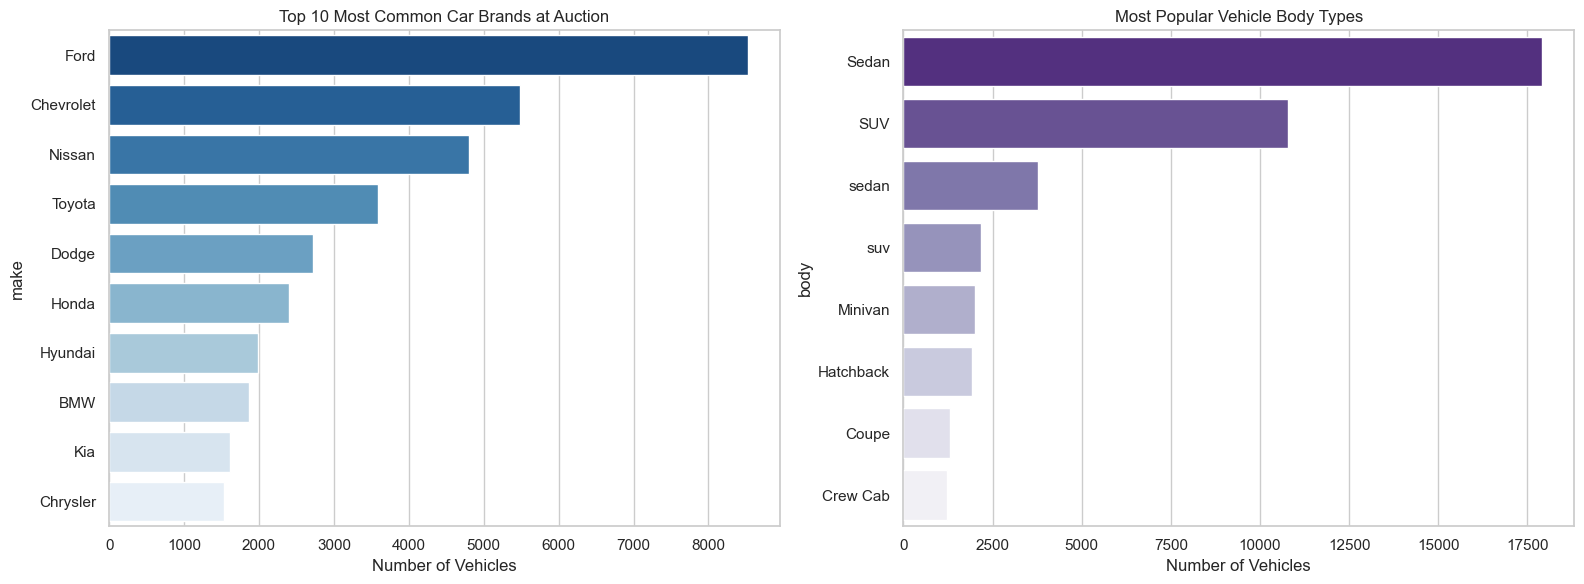

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 10 Car Brands (Fixed with hue and legend=False)
top_makes = sample_7_df['make'].value_counts().head(10)
sns.barplot(
    x=top_makes.values, 
    y=top_makes.index, 
    ax=axes[0], 
    hue=top_makes.index,  # Assigning y-variable to hue
    palette="Blues_r", 
    legend=False          # Keeps the plot clean without an unneeded legend box
)
axes[0].set_title("Top 10 Most Common Car Brands at Auction")
axes[0].set_xlabel("Number of Vehicles")

# 2. Most Common Body Styles (Fixed with hue, legend=False, and standard palette)
top_bodies = sample_7_df['body'].value_counts().head(8)
sns.barplot(
    x=top_bodies.values, 
    y=top_bodies.index, 
    ax=axes[1], 
    hue=top_bodies.index,  # Assigning y-variable to hue
    palette="Purples_r",  # Switched to a standard built-in palette
    legend=False
)
axes[1].set_title("Most Popular Vehicle Body Types")
axes[1].set_xlabel("Number of Vehicles")

plt.tight_layout()
plt.show()

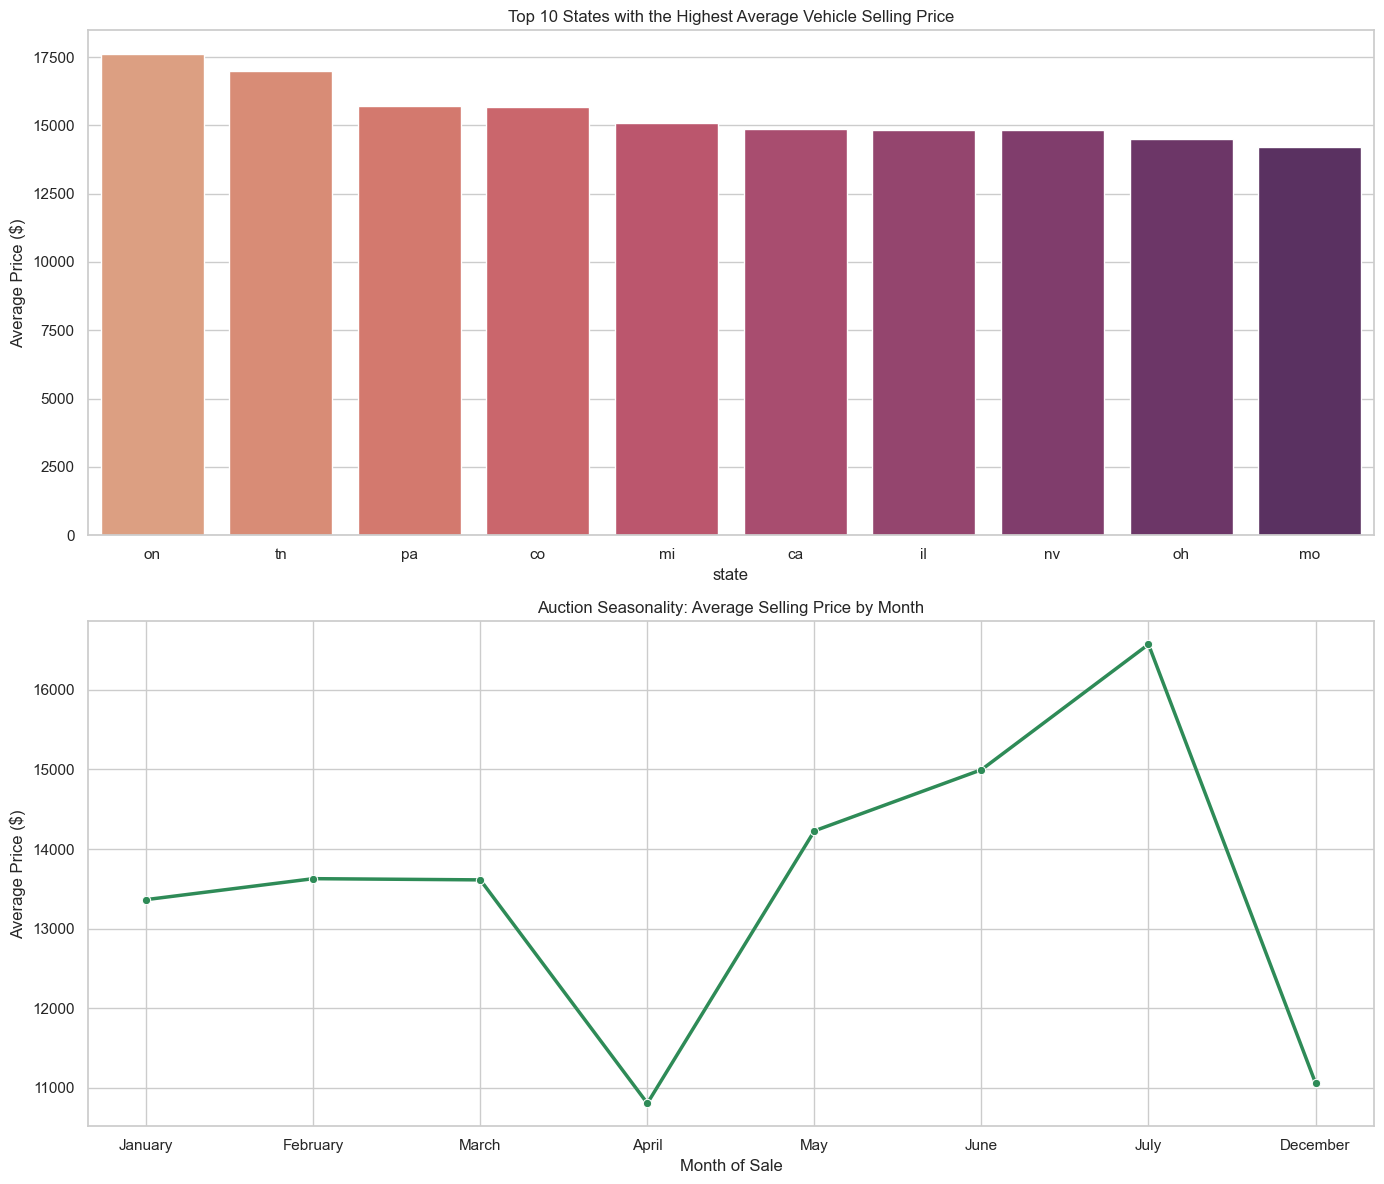

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Top 10 States by Average Selling Price (Fixed warning)
state_prices = sample_7_df.groupby('state')['sellingprice'].mean().sort_values(ascending=False).head(10)
sns.barplot(
    x=state_prices.index, 
    y=state_prices.values, 
    ax=axes[0], 
    hue=state_prices.index, # Assigning x-variable to hue
    palette="flare", 
    legend=False
)
axes[0].set_title("Top 10 States with the Highest Average Vehicle Selling Price")
axes[0].set_ylabel("Average Price ($)")

# 2. Price Trends Over Time (Lines don't throw this warning, so this remains the same)
sample_7_df['sale_month'] = sample_7_df['saledate'].dt.strftime('%B')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_prices = sample_7_df.groupby('sale_month')['sellingprice'].mean().reindex(month_order).dropna()

sns.lineplot(x=monthly_prices.index, y=monthly_prices.values, ax=axes[1], marker="o", linewidth=2.5, color="seagreen")
axes[1].set_title("Auction Seasonality: Average Selling Price by Month")
axes[1].set_ylabel("Average Price ($)")
axes[1].set_xlabel("Month of Sale")

plt.tight_layout()
plt.show()

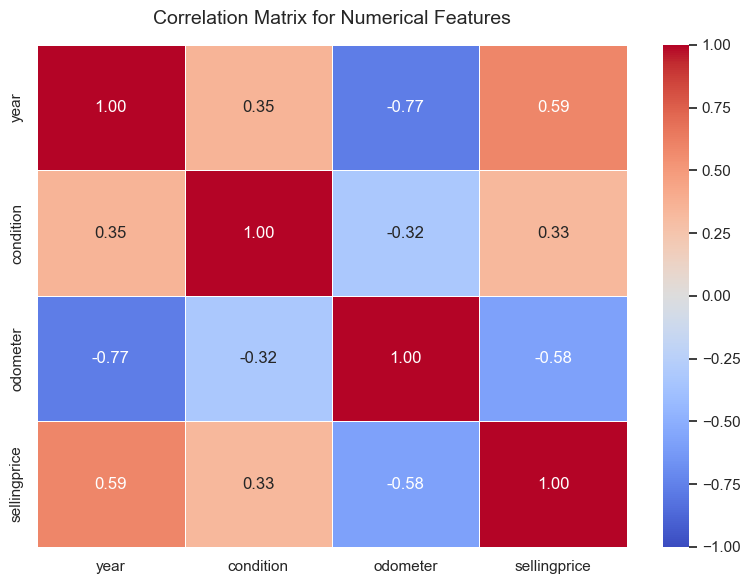

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the numerical columns
numerical_cols = ['year', 'condition', 'odometer', 'sellingprice']
corr_matrix = sample_7_df[numerical_cols].corr()

# 2. Set up the plotting window
plt.figure(figsize=(8, 6))

# 3. Create the heatmap
# - annot=True displays the actual numbers inside the squares
# - cmap="coolwarm" makes negative correlations blue and positive ones red
# - vmin/vmax locks the colorbar scale perfectly between -1 and 1
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1.0, 
    vmax=1.0
)

plt.title("Correlation Matrix for Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

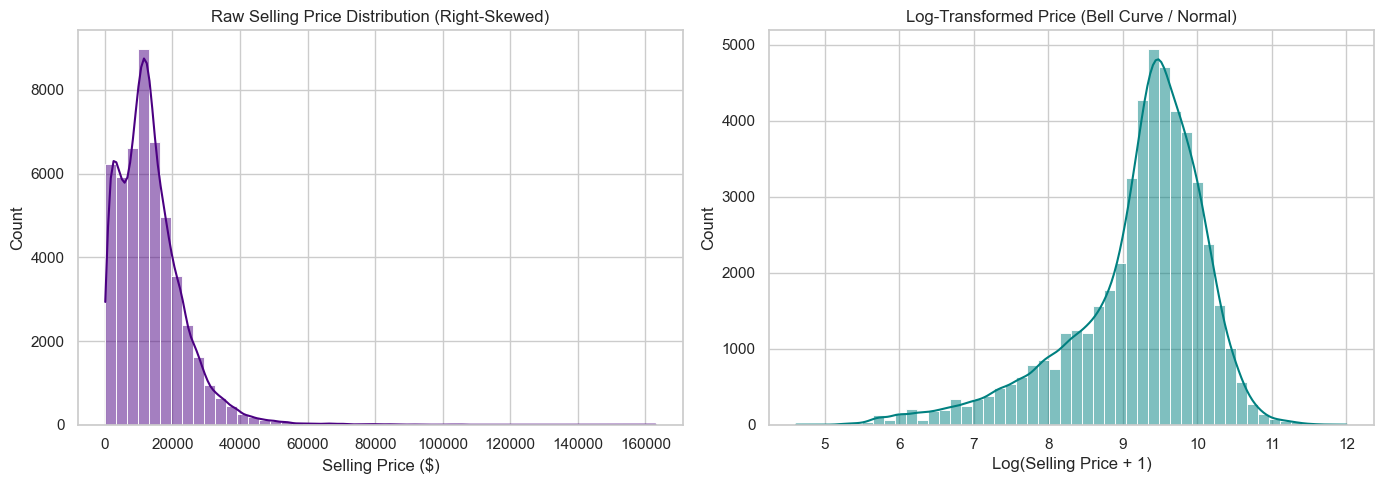

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Selling Price Distribution
sns.histplot(sample_7_df['sellingprice'], bins=50, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Raw Selling Price Distribution (Right-Skewed)')
axes[0].set_xlabel('Selling Price ($)')

# Plot 2: Log-Transformed Selling Price Distribution
sns.histplot(np.log1p(sample_7_df['sellingprice']), bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Price (Bell Curve / Normal)')
axes[1].set_xlabel('Log(Selling Price + 1)')

plt.tight_layout()
plt.show()

In [43]:
def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column] < lower_fence) | (dataframe[column] > upper_fence)]
    print(f"--- Outlier Report for '{column}' ---")
    print(f"Lower Statistical Fence: {lower_fence:.2f}")
    print(f"Upper Statistical Fence: {upper_fence:.2f}")
    print(f"Total Outliers Detected: {len(outliers)} rows ({len(outliers)/len(dataframe)*100:.2f}% of data)\n")
    return lower_fence, upper_fence

# Run the detector on price and mileage
price_lower, price_upper = find_outliers_iqr(sample_7_df, 'sellingprice')
odo_lower, odo_upper = find_outliers_iqr(sample_7_df, 'odometer')

--- Outlier Report for 'sellingprice' ---
Lower Statistical Fence: -10050.00
Upper Statistical Fence: 35150.00
Total Outliers Detected: 1490 rows (2.98% of data)

--- Outlier Report for 'odometer' ---
Lower Statistical Fence: -76903.75
Upper Statistical Fence: 204634.25
Total Outliers Detected: 999 rows (2.00% of data)



In [44]:
# Cross-examine how Transmission and Body Styles interact across the pricing matrix
pivot_market = sample_7_df.groupby(['body', 'transmission'])['sellingprice'].agg(['mean', 'count']).reset_index()

# Filter down to the top body styles to keep the analysis clean
top_5_bodies = sample_7_df['body'].value_counts().head(5).index
pivot_filtered = pivot_market[pivot_market['body'].isin(top_5_bodies)]

# Display the grouped perspective
print("--- Average Price & Volume by Body and Transmission Type ---")
print(pivot_filtered.to_string(index=False))

--- Average Price & Volume by Body and Transmission Type ---
   body transmission         mean  count
Minivan    automatic 11379.794500   2000
Minivan       manual  5150.000000      2
    SUV    automatic 15944.973916  10658
    SUV       manual 13420.312500    128
  Sedan    automatic 11583.955099  17505
  Sedan       manual  8071.191646    407
  sedan    automatic 12534.961777   3715
  sedan       manual 10315.833333     60
    suv    automatic 16850.957103   2168
    suv       manual 12897.058824     17


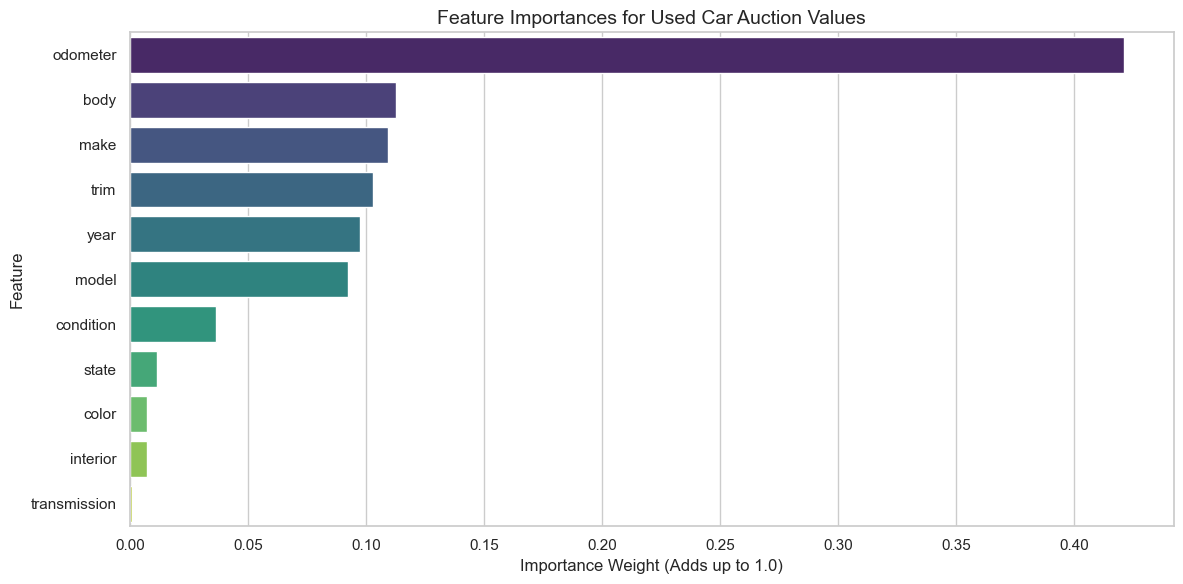

--- Exact Mathematical Weights ---
     Feature  Importance Score
    odometer          0.421233
        body          0.112797
        make          0.109452
        trim          0.102862
        year          0.097545
       model          0.092556
   condition          0.036413
       state          0.011545
       color          0.007454
    interior          0.007170
transmission          0.000973


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

# 1. Define your predictive targets and features
features = ['year', 'make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior']
target = 'sellingprice'

# Filter out rows missing your target variable 
clean_df = sample_7_df.dropna(subset=[target]).copy()

X = clean_df[features]
y = clean_df[target]

# 2. Encode text columns safely into numerical categories
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X = X.copy()
X[categorical_cols] = encoder.fit_transform(X[categorical_cols].astype(str))

# 3. Train/Test split (Using 80% to train and 20% to validate)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Fit the Random Forest model
# We set n_jobs=-1 to use all cores on your computer for maximum speed
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Extract and sort MDI (Mean Decrease in Impurity) Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Package the results into a clean DataFrame
fi_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance Score': [importances[i] for i in indices]
})

# 6. Plot the numerical results visually
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance Score', 
    y='Feature', 
    data=fi_df, 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Feature Importances for Used Car Auction Values', fontsize=14)
plt.xlabel('Importance Weight (Adds up to 1.0)')
plt.tight_layout()
plt.show()

# Print out the exact sorted table
print("--- Exact Mathematical Weights ---")
print(fi_df.to_string(index=False))

# Week 3 (Data preparation)

In [48]:
import os
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# 1. Configuration & Path Setup
INPUT_PATH = "../data/sample_7.csv"
OUTPUT_DIR = "../data/processed"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "processed_cars.csv")

print("⚡ Starting Preprocessing Pipeline...")

# Load Data
df = pd.read_csv(INPUT_PATH)

# ========================================================
# PHASE 1: CLEANING & IMPUTATION
# ========================================================
# Drop rows completely missing core prediction variables
df = df.dropna(subset=['sellingprice', 'saledate'])

# Numerical Imputation (Grouped by production year)
df['odometer'] = df.groupby('year')['odometer'].transform(lambda x: x.fillna(x.median()))
df['condition'] = df.groupby('year')['condition'].transform(lambda x: x.fillna(x.median()))

# Categorical Safety Fallback
categorical_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown').astype(str).str.lower().str.strip()

# ========================================================
# PHASE 2: FEATURE ENGINEERING
# ========================================================
# Extract Time-Series Components from saledate
df['saledate_clean'] = df['saledate'].str.split(' GMT').str[0]
df['saledate_clean'] = pd.to_datetime(df['saledate_clean'], format='%a %b %d %Y %H:%M:%S', errors='coerce')

df['sale_year'] = df['saledate_clean'].dt.year
df['sale_month'] = df['saledate_clean'].dt.month
df['sale_day_of_week'] = df['saledate_clean'].dt.dayofweek

# Fill any failed date parses with modal values
df['sale_year'] = df['sale_year'].fillna(df['sale_year'].mode()[0])
df['sale_month'] = df['sale_month'].fillna(df['sale_month'].mode()[0])
df['sale_day_of_week'] = df['sale_day_of_week'].fillna(df['sale_day_of_week'].mode()[0])

# ========================================================
# PHASE 3: LABEL ENCODING
# ========================================================
# Select variables prepared for model consumption
model_features = [
    'year', 'make', 'model', 'trim', 'body', 'transmission', 
    'state', 'condition', 'odometer', 'color', 'interior', 
    'sale_year', 'sale_month', 'sale_day_of_week', 'sellingprice'
]
processed_df = df[model_features].copy()

# Apply Ordinal/Label encoding across text features
encode_targets = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
processed_df[encode_targets] = encoder.fit_transform(processed_df[encode_targets])

# ========================================================
# PHASE 4: SAVE OUTPUT ASSET
# ========================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
processed_df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Data processed successfully! Saved shape: {processed_df.shape}")
print(f"📁 Destination: {OUTPUT_FILE}")

⚡ Starting Preprocessing Pipeline...
✅ Data processed successfully! Saved shape: (49998, 15)
📁 Destination: ../data/processed/processed_cars.csv


# Week 4 (Model training)

# Week 5 (Model deployment preparation)